In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/binaryclassificationwithabankchurndataset/sample_submission.csv
/kaggle/input/binaryclassificationwithabankchurndataset/train.csv
/kaggle/input/binaryclassificationwithabankchurndataset/test.csv


# **Bank mijozlarining qarzlarini qaytarish prognozi**

## Aim is to predict Exited column

### Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay, classification_report, confusion_matrix


In [6]:
train_set = pd.read_csv("/kaggle/input/binaryclassificationwithabankchurndataset/train.csv")
test_set = pd.read_csv("/kaggle/input/binaryclassificationwithabankchurndataset/test.csv")

## Exploring data

In [7]:
train_set.shape

(15000, 14)

In [10]:
train_set.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [8]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [9]:
train_set.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,14999.000000,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


In [11]:
df = train_set.drop(['id', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [12]:
print(df['Geography'].value_counts())

Geography
France     9040
Spain      3280
Germany    2680
Name: count, dtype: int64


In [13]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [20]:
from sklearn.preprocessing import OneHotEncoder

geography_dummies = pd.get_dummies(df['Geography'], prefix='Geography', drop_first=True)

df = pd.concat([df, geography_dummies], axis=1)

# Endi eski Geography ustunini o'chirish
df.drop('Geography', axis=1, inplace=True)

In [21]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,567.0,1,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0,False,False
1,628.0,0,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0,False,False
2,635.0,0,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0,False,False
3,681.0,1,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0,False,False
4,587.0,0,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0,False,False


## Correlation

In [22]:
df.corr().abs()
df.corr().abs().style.background_gradient(cmap = "coolwarm")

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,0.007726,0.010207,0.005782,0.011393,0.009826,0.000844,0.015396,0.015829,0.052375,0.003642,0.008816
Gender,0.007726,1.000000,0.076672,0.002521,0.017942,0.037970,0.004379,0.025260,0.008069,0.169465,0.043439,0.009388
Age,0.010207,0.076672,1.000000,0.012750,0.090285,0.169409,0.007544,0.026430,0.004344,0.449425,0.115275,0.022580
Tenure,0.005782,0.002521,0.012750,1.000000,0.014872,0.016087,0.021382,0.010231,0.008884,0.032897,0.015486,0.014916
Balance,0.011393,0.017942,0.090285,0.014872,1.000000,0.423496,0.018996,0.021580,0.003853,0.160062,0.622375,0.147111
NumOfProducts,0.009826,0.037970,0.169409,0.016087,0.423496,1.000000,0.001089,0.047784,0.002612,0.312812,0.148157,0.034371
HasCrCard,0.000844,0.004379,0.007544,0.021382,0.018996,0.001089,1.000000,0.026277,0.012787,0.010670,0.018072,0.007171
IsActiveMember,0.015396,0.025260,0.026430,0.010231,0.021580,0.047784,0.026277,1.000000,0.003154,0.188748,0.027943,0.025523
EstimatedSalary,0.015829,0.008069,0.004344,0.008884,0.003853,0.002612,0.012787,0.003154,1.000000,0.035193,0.001631,0.000481
Exited,0.052375,0.169465,0.449425,0.032897,0.160062,0.312812,0.010670,0.188748,0.035193,1.000000,0.242651,0.061859


In [23]:
df.corrwith(df['Exited']).abs().sort_values(ascending=False)

Exited               1.000000
Age                  0.449425
NumOfProducts        0.312812
Geography_Germany    0.242651
IsActiveMember       0.188748
Gender               0.169465
Balance              0.160062
Geography_Spain      0.061859
CreditScore          0.052375
EstimatedSalary      0.035193
Tenure               0.032897
HasCrCard            0.010670
dtype: float64

## Data Visualization

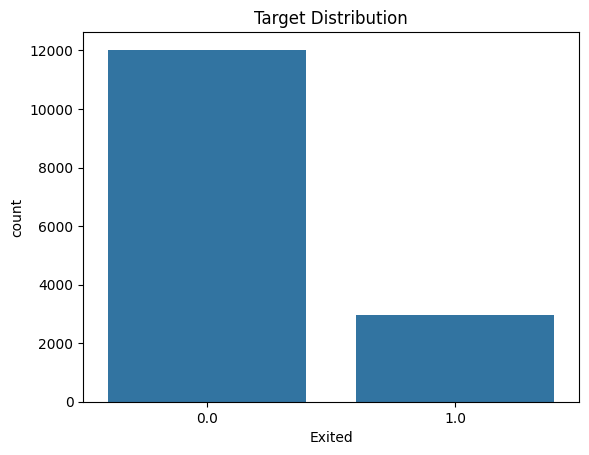

In [24]:
sns.countplot(x='Exited', data=df)
plt.title("Target Distribution")
plt.show()

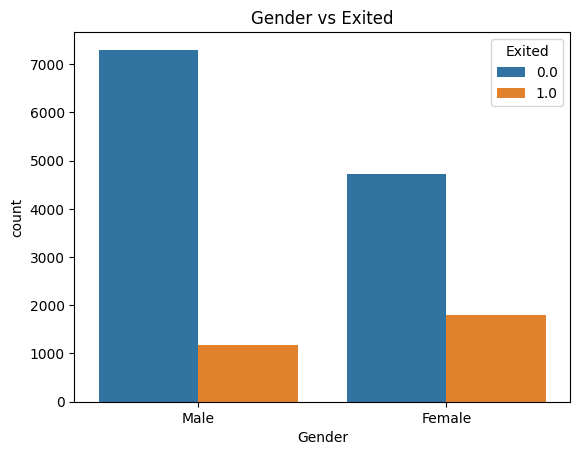

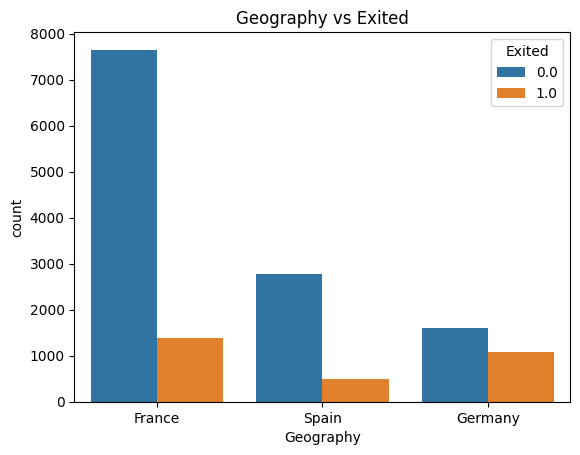

In [27]:
sns.countplot(x='Gender', hue='Exited', data=train_set)
plt.title("Gender vs Exited")
plt.show()

sns.countplot(x='Geography', hue='Exited', data=train_set)
plt.title("Geography vs Exited")
plt.show()

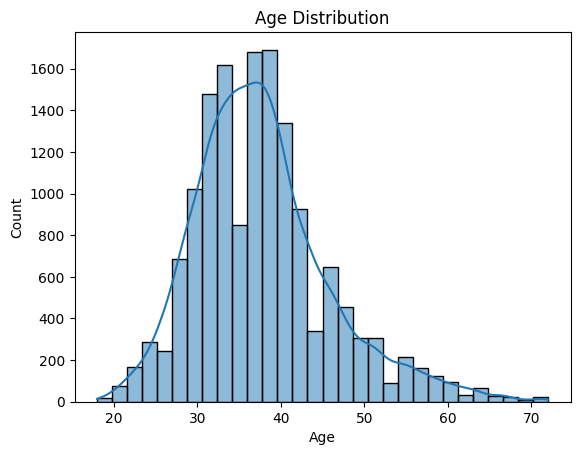

In [28]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

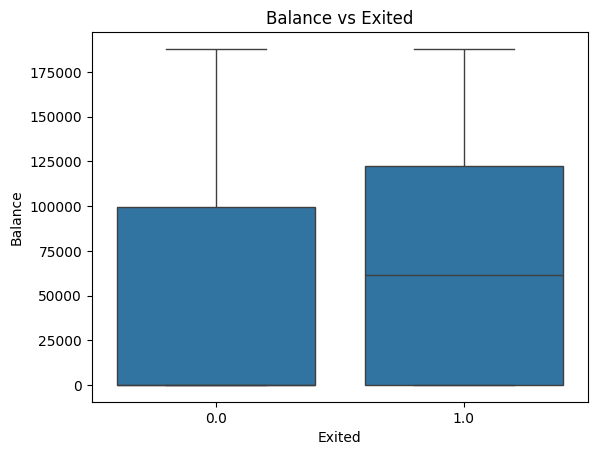

In [29]:
sns.boxplot(x='Exited', y='Balance', data=train_set)
plt.title("Balance vs Exited")
plt.show()

## Machine Learning (preparetion)

In [30]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# All Models with GridSearchCV

## Logistic Regression

In [33]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR params:", grid_lr.best_params_)
y_prob = grid_lr.predict_proba(X_test_scaled)[:,1]
print("Test AUC LR:", roc_auc_score(y_test, y_prob))


Best LR params: {'C': 0.01, 'solver': 'liblinear'}
Test AUC LR: 0.8842782019252607


## Random Forest

In [35]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
y_prob = grid_rf.predict_proba(X_test)[:,1]
print("Test AUC RF:", roc_auc_score(y_test, y_prob))

Best RF params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Test AUC RF: 0.9310581945876063


## XGBoost

In [37]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB params:", grid_xgb.best_params_)
y_prob = grid_xgb.predict_proba(X_test)[:,1]
print("Test AUC XGB:", roc_auc_score(y_test, y_prob))

Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Test AUC XGB: 0.9341941683118155


## Support Vector Machine (SVM)

In [40]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best SVM params:", grid_svm.best_params_)
y_prob = grid_svm.predict_proba(X_test_scaled)[:,1]
print("Test AUC SVM:", roc_auc_score(y_test, y_prob))

Best SVM params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Test AUC SVM: 0.9217806041335453


### Modellarning natijaviy qiymatlari!
Barchasi bitta kodda, chunki taqqoslashga qulay bo'lgani uchun


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      2405
         1.0       0.75      0.53      0.62       595

    accuracy                           0.87      3000
   macro avg       0.82      0.74      0.77      3000
weighted avg       0.86      0.87      0.86      3000



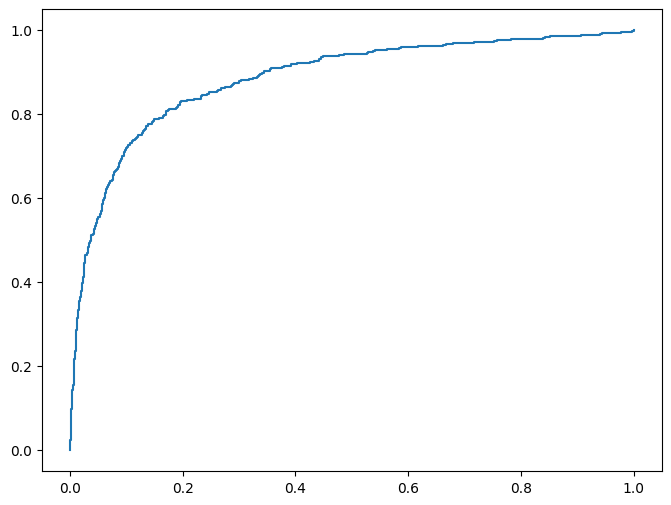

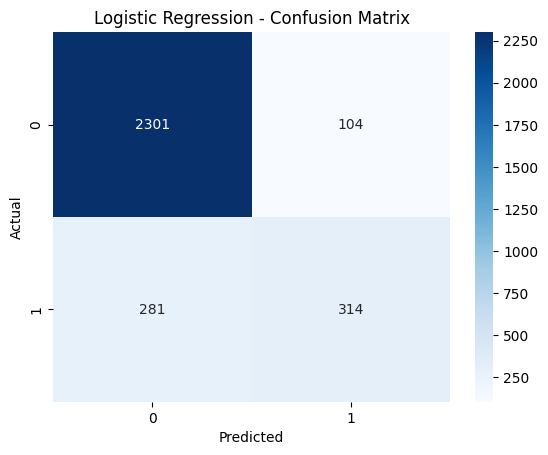


=== SVM Classification Report ===
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      2405
         1.0       0.81      0.57      0.67       595

    accuracy                           0.89      3000
   macro avg       0.85      0.77      0.80      3000
weighted avg       0.88      0.89      0.88      3000



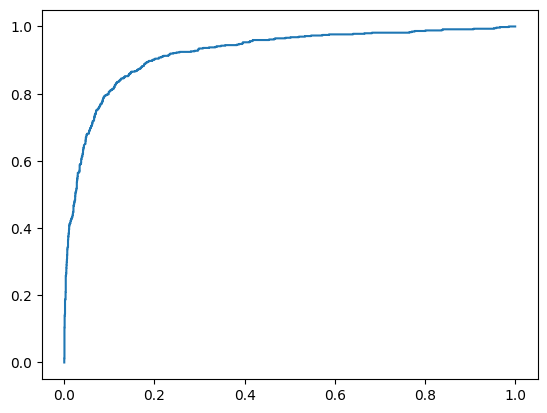

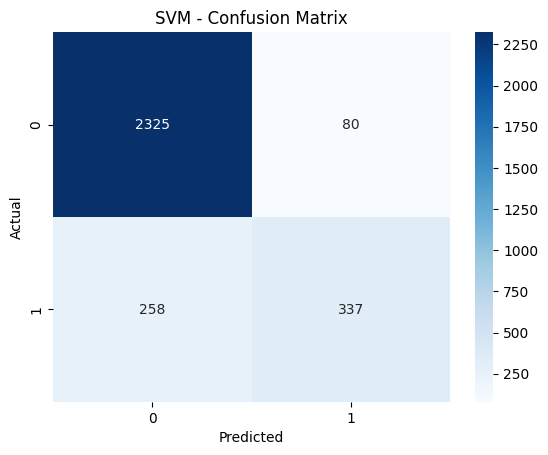


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2405
         1.0       0.79      0.66      0.71       595

    accuracy                           0.90      3000
   macro avg       0.85      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000



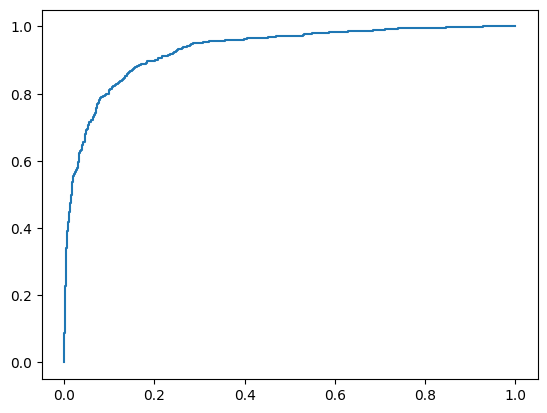

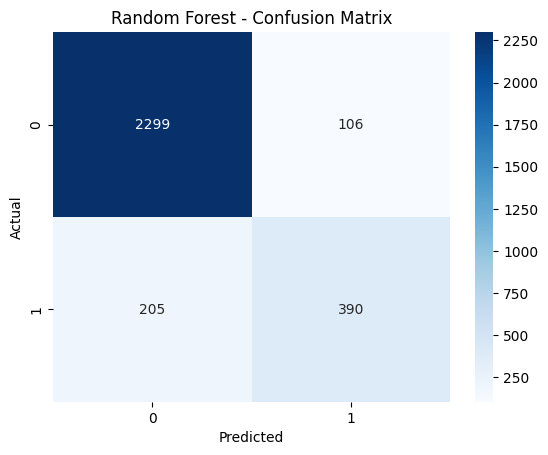


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2405
         1.0       0.80      0.67      0.73       595

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.90      0.90      0.90      3000



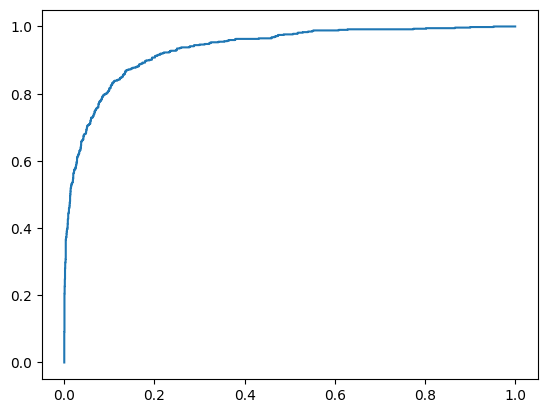

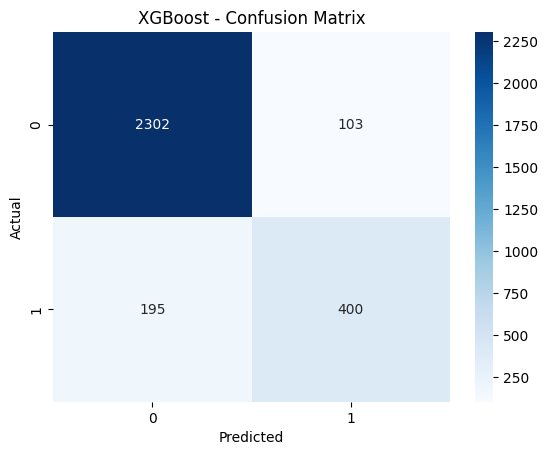

/tmp/ipykernel_55/3327760716.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


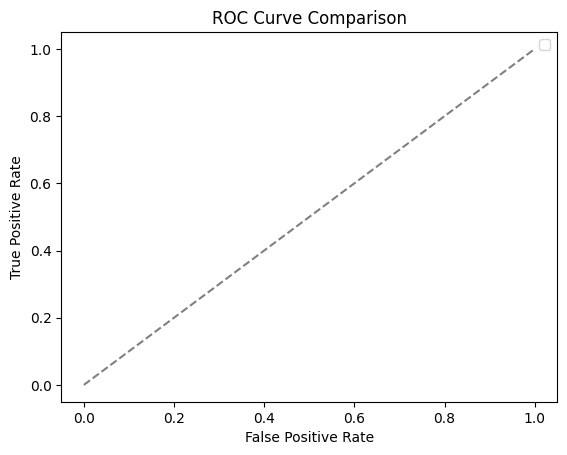

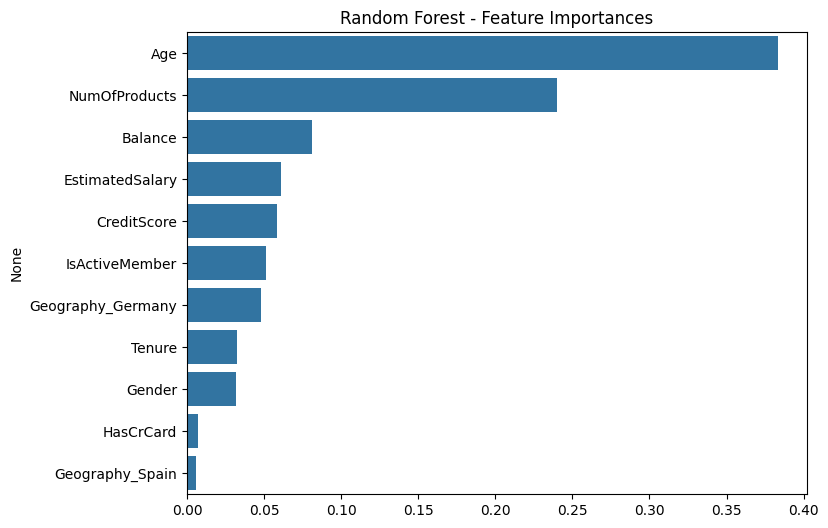

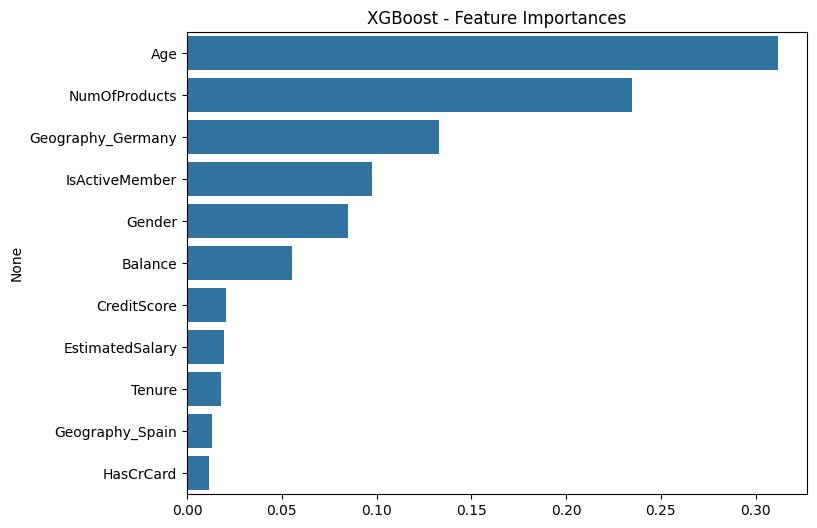

In [41]:
# Models dictionary (best estimators)
best_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "SVM": grid_svm.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

plt.figure(figsize=(8,6))

for name, model in best_models.items():
    if name in ['Logistic Regression', 'SVM']:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        y_pred = model.predict(X_test_scaled)
    else:
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
    
    # Classification Report
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Feature importance (Random Forest)
rf_model = best_models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.title("Random Forest - Feature Importances")
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.show()

# Feature importance (XGBoost)
xgb_model = best_models["XGBoost"]
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.title("XGBoost - Feature Importances")
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.show()

### Feature Importance aynan ushbu ikkita modelga qo'llanildi, chunki bu ikkita model qolganlariga qaraganda yaxshi natija berdi.
### Modellarni ROC-AUC score bilan taqqoslandi.
### Shug'ullantirilgan modellar ichida XGBoost modeli yuqoriroq AUC erishdi va shu sababli bu loyiha uchun ushbu model tanlab olindi

#### XGBoost model
#### Accuracy : 90
#### ROC-AUC : 0.93

Used Algorithms:

-Logistic Regression
-SVM
-Random Forest
-XGBoost

## Test Data

In [42]:
test_set.shape

(10000, 13)

In [44]:
test_set.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15732563.0,Hs?,707.0,Germany,Male,21.0,4.0,114513.66,2.0,1.0,0.0,176692.87
1,15001,15727041.0,Ma,678.0,Germany,Male,33.0,5.0,142510.50,1.0,0.0,0.0,52820.13
2,15002,15753679.0,K?,636.0,Spain,Male,45.0,9.0,0.00,2.0,1.0,1.0,125062.02
3,15003,15581554.0,H?,697.0,Spain,Male,46.0,8.0,0.00,2.0,1.0,0.0,131647.41
4,15004,15773723.0,Bellucci,553.0,Spain,Male,31.0,2.0,0.00,2.0,1.0,0.0,58814.41


In [ ]:
test_set = test_set.drop(['id', 'CustomerId', 'Surname'], axis=1)

In [46]:
test_set['"Gender'] = le.fit_transform(test_set['Gender'])

In [47]:
geography_dummies = pd.get_dummies(test_set['Geography'], prefix='Geography', drop_first=True)

dfs = pd.concat([test_set, geography_dummies], axis=1)

dfs.drop('Geography', axis=1, inplace=True)

In [48]:
dfs.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,707.0,1,21.0,4.0,114513.66,2.0,1.0,0.0,176692.87,True,False
1,678.0,1,33.0,5.0,142510.50,1.0,0.0,0.0,52820.13,True,False
2,636.0,1,45.0,9.0,0.00,2.0,1.0,1.0,125062.02,False,True
3,697.0,1,46.0,8.0,0.00,2.0,1.0,0.0,131647.41,False,True
4,553.0,1,31.0,2.0,0.00,2.0,1.0,0.0,58814.41,False,True


In [49]:
X_final_test_scaled = scaler.transform(dfs)

In [51]:
y_final_pred = grid_xgb.best_estimator_.predict(dfs)
y_final_prob = grid_xgb.best_estimator_.predict_proba(dfs)[:,1]  # probability
y_final_pred

array([0, 0, 0, ..., 1, 0, 0])

In [56]:
final = pd.DataFrame({"Exited": y_final_pred})

In [57]:
final.to_csv("submission_file.csv")
print("submission file saved")

submission file saved


Kaggle Username : dildoratoxtasinova